# 04 — Training the Neural ODE Autoencoder

This notebook trains the Neural ODE Autoencoder on benign-only network traffic.

All hyperparameters are read from `configs/default.yaml` — the table below is printed from config at runtime.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import time
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange

from src.model import NeuralODEAutoencoder
from src.dataset import get_dataloaders
from src.train import train_one_epoch, validate

with open('../configs/default.yaml') as f:
    config = yaml.safe_load(f)

print(f'PyTorch {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}  MPS: {torch.backends.mps.is_available()}')

PyTorch 2.11.0
CUDA: False  MPS: True


## 1. Setup

In [2]:
# Device — torchdiffeq has limited MPS support, use CUDA if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Reproducibility
SEED = config['preprocessing']['random_state']
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


In [3]:
# Data
batch_size = config['training']['batch_size']
loaders = get_dataloaders('../data/processed', batch_size)

for split, loader in loaders.items():
    ds = loader.dataset
    n_attack = int(ds.y.sum())
    n_benign = len(ds) - n_attack
    print(f'{split:5s}: {len(ds):,} windows  (benign={n_benign:,}, attack={n_attack:,})')

train: 69,918 windows  (benign=69,918, attack=0)
val  : 18,959 windows  (benign=14,982, attack=3,977)
test : 18,959 windows  (benign=14,982, attack=3,977)


In [4]:
# Model
model = NeuralODEAutoencoder(config).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}  (~{n_params * 4 / 1024 / 1024:.1f} MB)')
print()
print(model)

Parameters: 1,173,074  (~4.5 MB)

NeuralODEAutoencoder(
  (encoder): BiGRUEncoder(
    (gru): GRU(49, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (projection): Linear(in_features=256, out_features=32, bias=True)
  )
  (ode_func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=33, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): SiLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): SiLU()
      (6): Linear(in_features=128, out_features=32, bias=True)
    )
  )
  (decoder): MLPDecoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): SiLU()
      (3): Dropout(p=0.2, inplace=Fal

In [5]:
# All hyperparameters from config
train_cfg = config['training']
model_cfg = config['model']

EPOCHS = train_cfg['epochs']
LR = train_cfg['learning_rate']
WEIGHT_DECAY = train_cfg['weight_decay']
PATIENCE = train_cfg['early_stopping_patience']
GRAD_CLIP = train_cfg['grad_clip']
LAMBDA_KE = train_cfg['lambda_ke']

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('=== Training Hyperparameters ===')
print(f'  Max epochs:          {EPOCHS}')
print(f'  Batch size:          {batch_size}')
print(f'  Learning rate:       {LR}')
print(f'  Weight decay:        {WEIGHT_DECAY}')
print(f'  Gradient clipping:   {GRAD_CLIP}')
print(f'  KE regularization:   lambda={LAMBDA_KE}')
print(f'  Scheduler:           Cosine Annealing (T_max={EPOCHS})')
print(f'  Early stopping:      patience={PATIENCE}')
print()
print('=== Model Hyperparameters ===')
print(f'  Input dim:           {model_cfg["input_dim"]}')
print(f'  Encoder:             BiGRU, hidden={model_cfg["encoder"]["hidden_size"]}, '
      f'layers={model_cfg["encoder"]["num_layers"]}, dropout={model_cfg["encoder"]["dropout"]}, '
      f'layer_norm={model_cfg["encoder"]["layer_norm"]}')
print(f'  Latent dim:          {model_cfg["latent_dim"]}')
print(f'  ODE dynamics:        hidden={model_cfg["neural_ode"]["hidden_size"]}, '
      f'layers={model_cfg["neural_ode"]["num_layers"]}, solver={model_cfg["neural_ode"]["solver"]}, '
      f'layer_norm={model_cfg["neural_ode"]["layer_norm"]}, ke_steps={model_cfg["neural_ode"]["ke_n_steps"]}')
print(f'  Decoder:             hidden={model_cfg["decoder"]["hidden_size"]}, '
      f'layers={model_cfg["decoder"]["num_layers"]}, dropout={model_cfg["decoder"]["dropout"]}, '
      f'layer_norm={model_cfg["decoder"]["layer_norm"]}')
print()
print(f'  Train batches:       {len(loaders["train"])}')
print(f'  Val batches:         {len(loaders["val"])}')

=== Training Hyperparameters ===
  Max epochs:          200
  Batch size:          256
  Learning rate:       0.001
  Weight decay:        1e-05
  Gradient clipping:   1.0
  KE regularization:   lambda=0.01
  Scheduler:           Cosine Annealing (T_max=200)
  Early stopping:      patience=10

=== Model Hyperparameters ===
  Input dim:           49
  Encoder:             BiGRU, hidden=128, layers=2, dropout=0.2, layer_norm=True
  Latent dim:          32
  ODE dynamics:        hidden=128, layers=3, solver=dopri5, layer_norm=True, ke_steps=10
  Decoder:             hidden=256, layers=3, dropout=0.2, layer_norm=True

  Train batches:       273
  Val batches:         75


## 2. Training

Training and validation functions are defined in `src/train.py` and support an optional `pbar` argument for progress bars.

In [6]:
# Training history
history = {
    'total_loss': [],
    'mse_loss': [],
    'ke_loss': [],
    'val_loss': [],
    'lr': [],
    'epoch_time': [],
}

# Early stopping state
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0
best_state_dict = None

n_train_batches = len(loaders['train'])
n_val_batches = len(loaders['val'])

epoch_pbar = trange(1, EPOCHS + 1, desc='Training', unit='epoch')

for epoch in epoch_pbar:
    t0 = time.time()

    # Train: returns (total_loss, mse_loss, ke_loss)
    with tqdm(total=n_train_batches, desc=f'Epoch {epoch} [train]',
              leave=False, unit='batch') as batch_pbar:
        total_loss, mse_loss, ke_loss = train_one_epoch(
            model, loaders['train'], optimizer, device, GRAD_CLIP, LAMBDA_KE, pbar=batch_pbar)

    # Validate: benign-only MSE
    with tqdm(total=n_val_batches, desc=f'Epoch {epoch} [val]',
              leave=False, unit='batch') as batch_pbar:
        val_loss = validate(model, loaders['val'], device, pbar=batch_pbar)

    lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = time.time() - t0

    history['total_loss'].append(total_loss)
    history['mse_loss'].append(mse_loss)
    history['ke_loss'].append(ke_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(lr)
    history['epoch_time'].append(elapsed)

    # Early stopping
    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    status = 'new best' if improved else f'wait {patience_counter}/{PATIENCE}'
    epoch_pbar.set_postfix({
        'mse': f'{mse_loss:.4f}',
        'ke': f'{ke_loss:.4f}',
        'val': f'{val_loss:.4f}',
        'best': f'{best_val_loss:.4f}',
        'lr': f'{lr:.1e}',
        'status': status,
    })

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.6f} at epoch {best_epoch}')
print(f'Total time: {sum(history["epoch_time"]):.0f}s ({sum(history["epoch_time"])/60:.1f} min)')

Training:   0%|          | 0/200 [00:00<?, ?epoch/s]

Epoch 1 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Epoch 1 [val]:   0%|          | 0/75 [00:00<?, ?batch/s]

Epoch 2 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Epoch 2 [val]:   0%|          | 0/75 [00:00<?, ?batch/s]

...

Epoch 199 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Epoch 199 [val]:   0%|          | 0/75 [00:00<?, ?batch/s]

Epoch 200 [train]:   0%|          | 0/273 [00:00<?, ?batch/s]

Epoch 200 [val]:   0%|          | 0/75 [00:00<?, ?batch/s]


Best val loss: 6308916694558092.000000 at epoch 197
Total time: 13627s (227.1 min)


## 3. Training Curves

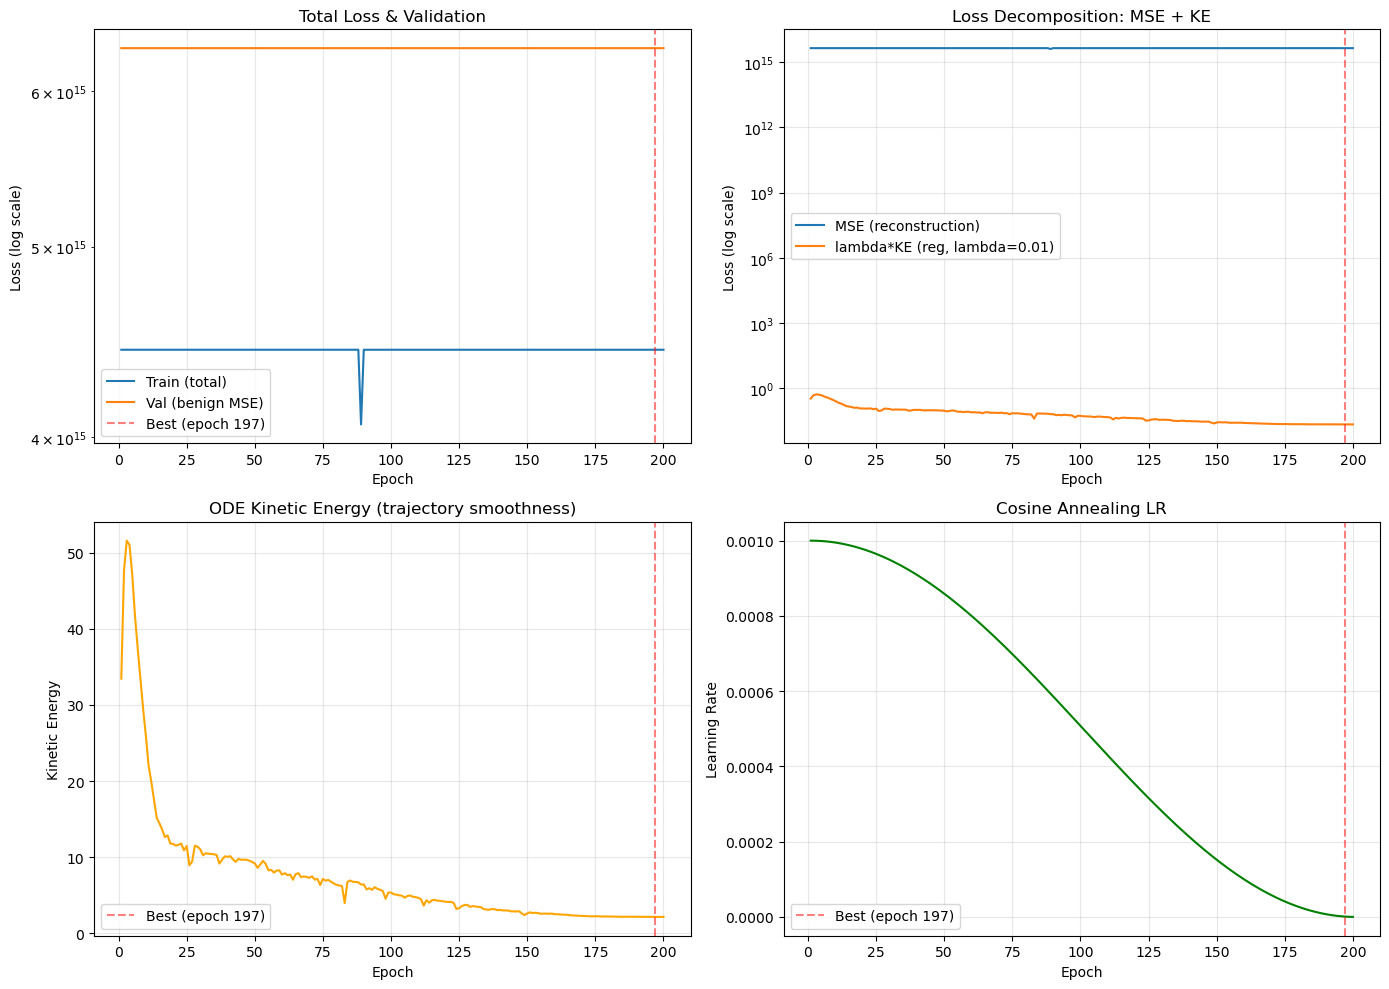

In [7]:
n_epochs = len(history['total_loss'])
epochs_range = range(1, n_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Total loss + val (log) ---
ax = axes[0, 0]
ax.plot(epochs_range, history['total_loss'], '-', label='Train (total)', linewidth=1.5)
ax.plot(epochs_range, history['val_loss'], '-', label='Val (benign MSE)', linewidth=1.5)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Total Loss & Validation')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# --- MSE vs KE decomposition ---
ax = axes[0, 1]
ax.plot(epochs_range, history['mse_loss'], '-', label='MSE (reconstruction)', linewidth=1.5)
ax.plot(epochs_range, [LAMBDA_KE * ke for ke in history['ke_loss']], '-',
        label=f'lambda*KE (reg, lambda={LAMBDA_KE})', linewidth=1.5)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Loss Decomposition: MSE + KE')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Kinetic energy (raw) ---
ax = axes[1, 0]
ax.plot(epochs_range, history['ke_loss'], '-', color='orange', linewidth=1.5)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Kinetic Energy')
ax.set_title('ODE Kinetic Energy (trajectory smoothness)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Learning rate ---
ax = axes[1, 1]
ax.plot(epochs_range, history['lr'], 'g-', linewidth=1.5)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Cosine Annealing LR')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/training_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
# Per-epoch timing
times = history['epoch_time']
print(f'Epoch time:  mean={np.mean(times):.1f}s  min={np.min(times):.1f}s  max={np.max(times):.1f}s')
print(f'Total time:  {sum(times):.0f}s ({sum(times)/60:.1f} min)')

Epoch time:  mean=68.1s  min=66.1s  max=71.9s
Total time:  13627s (227.1 min)


## 4. Save Checkpoint

In [9]:
checkpoint_dir = '../checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint = {
    'epoch': best_epoch,
    'model_state_dict': best_state_dict,
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': history['total_loss'][best_epoch - 1],
    'val_loss': best_val_loss,
    'config': config,
    'history': history,
}

path = os.path.join(checkpoint_dir, 'best.pt')
torch.save(checkpoint, path)

print(f'Checkpoint saved: {path}')
print(f'  Best epoch:  {best_epoch}')
print(f'  Val loss:    {best_val_loss:.6f}')
print(f'  File size:   {os.path.getsize(path) / 1024 / 1024:.1f} MB')

Checkpoint saved: ../checkpoints/best.pt
  Best epoch:  197
  Val loss:    6308916694558092.000000
  File size:   13.5 MB


## 5. Evaluation Preview

Quick look at anomaly score separation on the validation set using `src.evaluate`.

In [10]:
from src.evaluate import compute_anomaly_scores

# Load best weights
model.load_state_dict(best_state_dict)
model.eval()

scores, labels = compute_anomaly_scores(model, loaders['val'], device)

benign_scores = scores[labels == 0]
attack_scores = scores[labels == 1]

print(f'Benign:  mean={benign_scores.mean():.4f}  median={np.median(benign_scores):.4f}  std={benign_scores.std():.4f}')
print(f'Attack:  mean={attack_scores.mean():.4f}  median={np.median(attack_scores):.4f}  std={attack_scores.std():.4f}')
print(f'Ratio:   attack_mean / benign_mean = {attack_scores.mean() / max(benign_scores.mean(), 1e-10):.2f}x')

Benign:  mean=6498215725629440.0000  median=9427137593344.0000  std=inf
Attack:  mean=4472271536128.0000  median=3842168061952.0000  std=2541722796032.0000
Ratio:   attack_mean / benign_mean = 0.00x


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


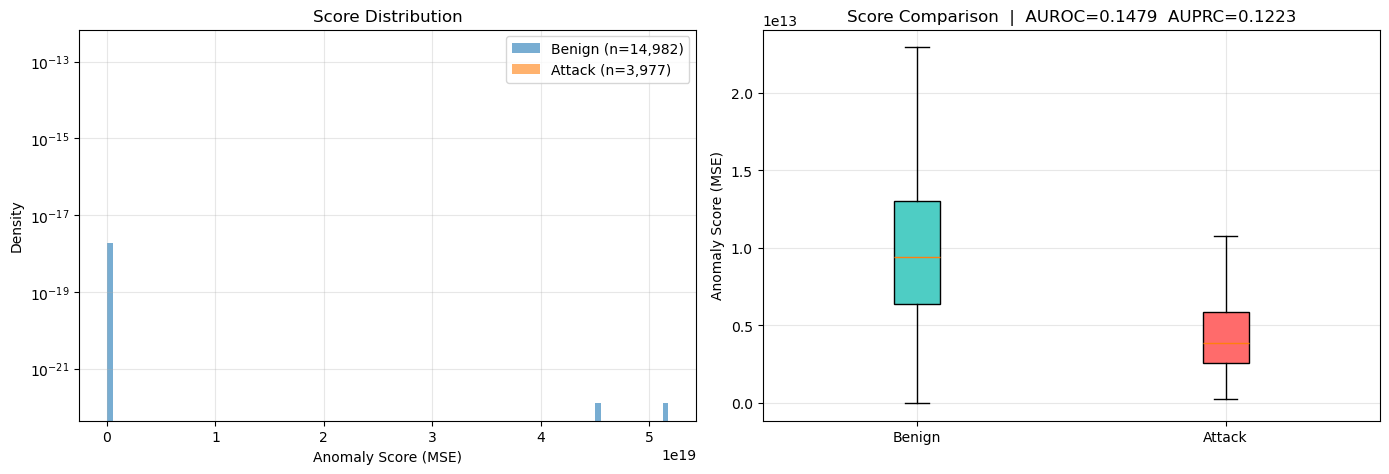

AUROC: 0.1479
AUPRC: 0.1223


In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

auroc = roc_auc_score(labels, scores)
auprc = average_precision_score(labels, scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distributions
ax = axes[0]
ax.hist(benign_scores, bins=100, alpha=0.6, label=f'Benign (n={len(benign_scores):,})', density=True)
ax.hist(attack_scores, bins=100, alpha=0.6, label=f'Attack (n={len(attack_scores):,})', density=True)
ax.set_xlabel('Anomaly Score (MSE)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1]
bp = ax.boxplot(
    [benign_scores, attack_scores],
    labels=['Benign', 'Attack'],
    patch_artist=True,
    showfliers=False,
)
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][1].set_facecolor('#FF6B6B')
ax.set_ylabel('Anomaly Score (MSE)')
ax.set_title(f'Score Comparison  |  AUROC={auroc:.4f}  AUPRC={auprc:.4f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/training_eval_preview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'AUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')

## Summary

| Metric | Value |
|--------|-------|
| Best epoch | see above |
| Best val loss | see above |
| Val AUROC | see above |
| Val AUPRC | see above |
| Total training time | see above |

Checkpoint saved at `checkpoints/best.pt`. Proceed to full evaluation in `05_evaluation.ipynb`.